In [12]:
import numpy as np

def sinusoidal(t, A, B, C, D):
    return A * np.sin(B * t + C) + D

Estimate Initial Parameters
A: Half the range of your data (e.g., (max(y)−min(y))/2).
B: Use a rough estimate for the frequency based on the periodicity observed.
C: Start with 0 or estimate based on phase.
D: Use the mean value of your data.

In [44]:
from scipy.optimize import curve_fit
import pandas as pd
from datetime import datetime

date_string = '20241017'
date = datetime.strptime(date_string, '%Y%m%d')

df_heights = pd.read_csv('data/well_heights.csv')
df_heights['date'] = pd.to_datetime(df_heights['date'], format='%d-%m-%Y')
df_heights = df_heights.set_index('date')
heights = pd.to_numeric(df_heights.loc[date].values, errors='coerce') / 100

data = pd.read_csv(f'data/{date_string}/logger_01.csv', skiprows=1)
data.columns = data.columns.str.strip()
data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d-%m-%y %H:%M:%S', dayfirst=True)

# Your data
t = np.array(data['datetime'])  # Independent variable (time)
y = np.array(data['Meters'])  # Dependent variable (data)

y += -1.9 + heights[0]

time_lims = [0.2, .95]

# print(t[int(len(t)*time_lims[0])], t[int(len(t)*time_lims[1])])

print(t[10], t[2000])

t = (t - t[0]).astype('timedelta64[s]').astype(float)

print(t[10], t[10000])

t = t[int(len(t)*time_lims[0]): int(len(t)*time_lims[1])]
y = y[int(len(y)*time_lims[0]): int(len(y)*time_lims[1])]

# Initial guess for parameters: A, B, C, D
initial_guess = [(max(y) - min(y))/2, 0.00002236, 0, -1.25]

# Perform the curve fitting
params, covariance = curve_fit(sinusoidal, t, y, p0=initial_guess)

# Extract fitted parameters
A_fit, B_fit, C_fit, D_fit = params

print(f"Fitted Parameters:\nAmplitude: {A_fit}\nFrequency: {B_fit / (2 * np.pi)}\nPhase: {C_fit}\nOffset: {D_fit}")


2024-10-17T11:30:25.000000000 2024-10-17T12:03:35.000000000
10.0 10000.0
Fitted Parameters:
Amplitude: 0.38752611052484826
Frequency: 4.61420142920133e-05
Phase: -2.71258624564184
Offset: -1.2577938735614482


Fitted Period: 6 hours and 1 minutes


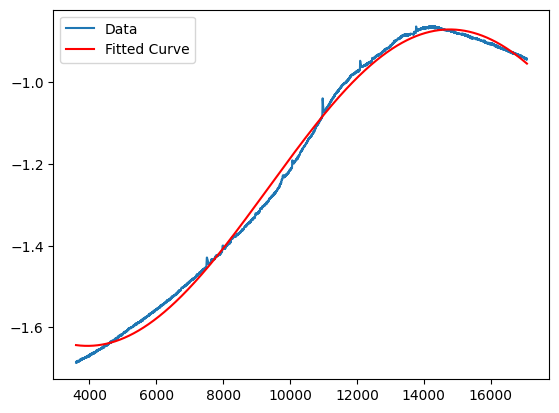

In [49]:
import matplotlib.pyplot as plt

B_M2 = 2 * np.pi / 44712

# Generate fitted values
y_fit = sinusoidal(t, A_fit, B_fit, C_fit, D_fit)

# Compute the period in seconds
fitted_period = 2 * np.pi / B_fit

# Convert seconds to hours and minutes
fitted_period_hours = int(fitted_period // 3600)  # Get hours
fitted_period_minutes = int((fitted_period % 3600) // 60)  # Get remaining minutes

# Print the result
print(f"Fitted Period: {fitted_period_hours} hours and {fitted_period_minutes} minutes")

# Plot
plt.plot(t, y, label="Data")
plt.plot(t, y_fit, color='red', label="Fitted Curve")
plt.legend()
plt.show()